# 08 — Integration de 3 datasets sociaux et Pipeline V2

**Objectif** : Integrer FakeNewsNet, CONSTRAINT 2021 et Credibility Corpus
pour reduire le domain shift articles → posts Bluesky.

Le pipeline V1.5 entraine sur des articles longs (~340 mots) classait 77%
des posts Bluesky courts (~27 mots) comme SUSPECT. En ajoutant ~41K textes
courts (titres, tweets), le V2 devrait mieux generaliser.

In [1]:
# Cell 1 — Setup et exploration des datasets
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_proj = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) != 'notebooks':
    os.chdir(os.path.join(_proj, 'notebooks'))
    _proj = os.path.abspath('..')
sys.path.insert(0, os.path.join(_proj, 'src'))

from pipeline.expert_detector import DatasetCleaner, ExpertFakeNewsDetector, LinguisticFeatureExtractor

DATA = os.path.join(_proj, 'data', 'training')

# Charger les 3 nouveaux datasets individuellement pour exploration
df_fnn = DatasetCleaner.load_fakenewsnet(os.path.join(DATA, 'fakenewsnet'), remove_short=3)
df_cst = DatasetCleaner.load_constraint(os.path.join(DATA, 'constraint'), remove_short=3)
df_cc  = DatasetCleaner.load_credibility_corpus(os.path.join(DATA, 'credibility_corpus'), remove_short=3)

# Stats par dataset
for name, df in [('FakeNewsNet', df_fnn), ('CONSTRAINT', df_cst), ('Credibility Corpus', df_cc)]:
    wlen = df['text_clean'].str.split().str.len()
    lang_info = f", Langues: {df['language'].value_counts().to_dict()}" if 'language' in df.columns else ", EN"
    print(f"\n{name}:")
    print(f"  Total: {len(df)} textes")
    print(f"  Labels: {df['label'].value_counts().to_dict()}")
    print(f"  Longueur mots — moy: {wlen.mean():.1f}, med: {wlen.median():.0f}, min: {wlen.min()}, max: {wlen.max()}{lang_info}")
    print(f"  Exemples:")
    for i in range(min(3, len(df))):
        print(f"    [{df['label'].iloc[i]}] {df['text_clean'].iloc[i][:100]}")


FakeNewsNet:
  Total: 22596 textes
  Labels: {0: 16987, 1: 5609}
  Longueur mots — moy: 11.6, med: 11, min: 3, max: 53, EN
  Exemples:
    [1] did miley cyrus and liam hemsworth secretly get married
    [1] paris jackson cara delevingne enjoy night out in matching outfits they have amazing chemistry
    [1] celebrities join tax march in protest of donald trump

CONSTRAINT:
  Total: 8559 textes
  Labels: {0: 4479, 1: 4080}
  Longueur mots — moy: 27.0, med: 25, min: 3, max: 1502, EN
  Exemples:
    [0] the cdc currently reports 99031 deaths in general the discrepancies in death counts between differen
    [0] states reported 1121 deaths a small rise from last tuesday southern states reported 640 of those dea
    [1] politically correct woman almost uses pandemic as excuse not to reuse plastic bag coronavirus nashvi

Credibility Corpus:
  Total: 9841 textes
  Labels: {0: 7522, 1: 2319}
  Longueur mots — moy: 17.3, med: 16, min: 3, max: 133, Langues: {'fr': 6149, 'en': 3692}
  Exemples:
 

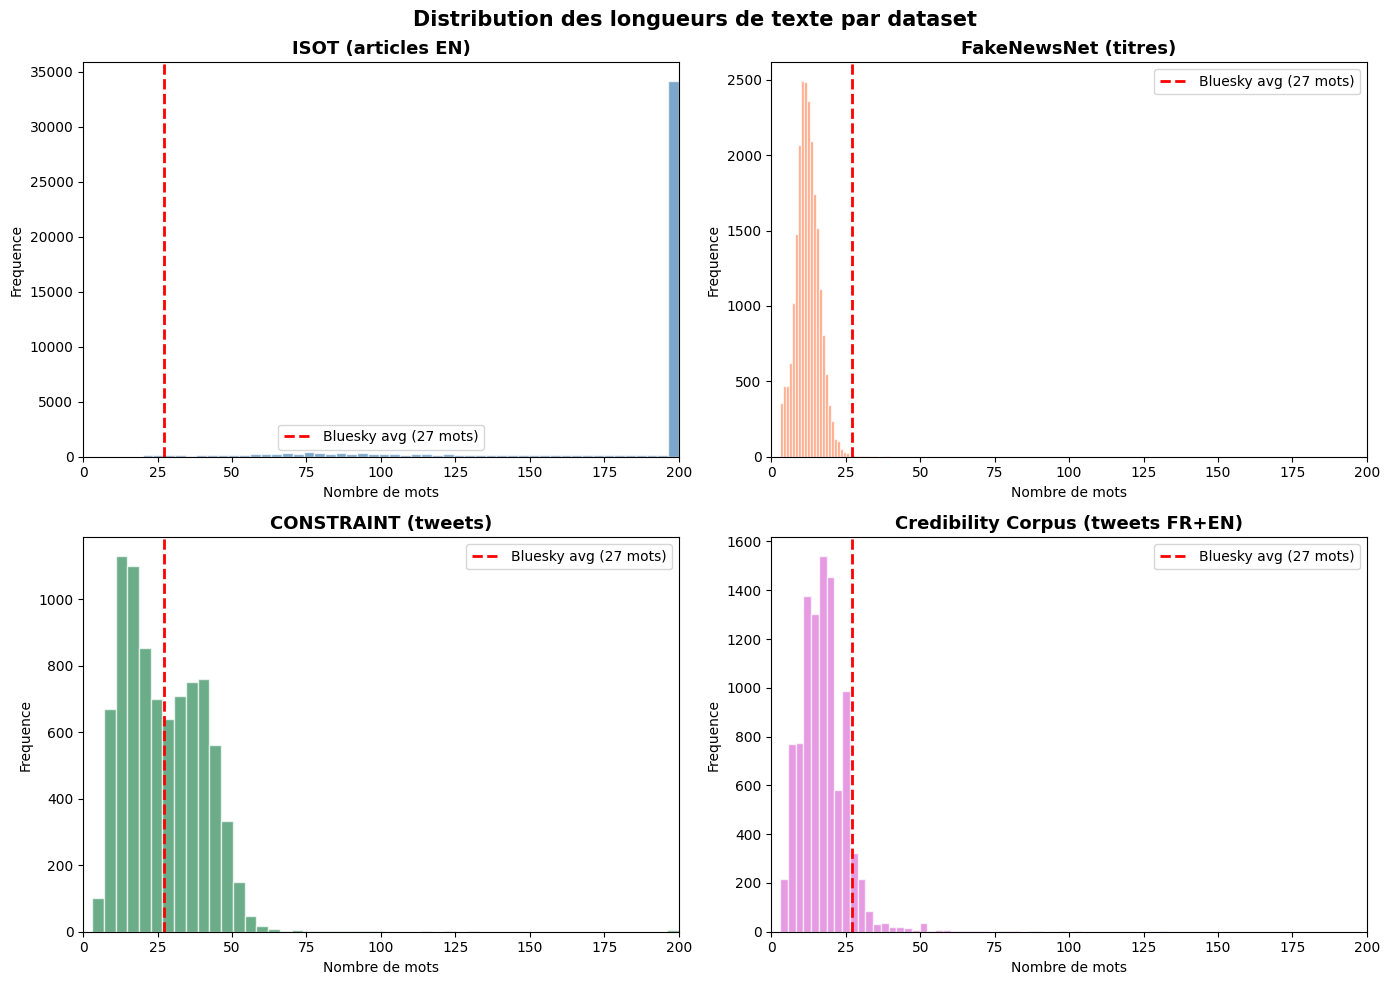


Graphique sauvegarde dans docs/dataset_length_distributions.png


In [2]:
# Cell 2 — Distribution des longueurs comparee
# Charger aussi les articles ISOT originaux pour comparaison
df_isot = DatasetCleaner.prepare_clean_dataset(
    os.path.join(DATA, 'Fake.csv'),
    os.path.join(DATA, 'True.csv'),
    remove_short=20
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_plot = [
    ('ISOT (articles EN)', df_isot, 'steelblue'),
    ('FakeNewsNet (titres)', df_fnn, 'coral'),
    ('CONSTRAINT (tweets)', df_cst, 'seagreen'),
    ('Credibility Corpus (tweets FR+EN)', df_cc, 'orchid'),
]

for ax, (name, df, color) in zip(axes.flat, datasets_plot):
    wlen = df['text_clean'].str.split().str.len().clip(upper=200)
    ax.hist(wlen, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(27, color='red', linestyle='--', linewidth=2, label='Bluesky avg (27 mots)')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Frequence')
    ax.legend()
    ax.set_xlim(0, 200)

plt.suptitle('Distribution des longueurs de texte par dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(_proj, 'docs', 'dataset_length_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\nGraphique sauvegarde dans docs/dataset_length_distributions.png")

In [3]:
# Cell 3 — Construction du dataset V2 bilingue
print("=" * 60)
print("CONSTRUCTION DU DATASET V2")
print("=" * 60)

# V1.5 (reference)
df_v15 = DatasetCleaner.prepare_bilingual_dataset(
    os.path.join(DATA, 'Fake.csv'),
    os.path.join(DATA, 'True.csv'),
    kaggle_fr_dir=os.path.join(DATA, 'kaggle_fr'),
)
print(f"\nV1.5: {len(df_v15)} articles | EN={sum(df_v15.language=='en')} FR={sum(df_v15.language=='fr')}")
print(f"  Labels: {df_v15.label.value_counts().to_dict()}")
print(f"  Longueur moyenne: {df_v15.text_clean.str.split().str.len().mean():.1f} mots")

# V2 (avec social)
df_v2 = DatasetCleaner.prepare_bilingual_dataset(
    os.path.join(DATA, 'Fake.csv'),
    os.path.join(DATA, 'True.csv'),
    kaggle_fr_dir=os.path.join(DATA, 'kaggle_fr'),
    fakenewsnet_dir=os.path.join(DATA, 'fakenewsnet'),
    constraint_dir=os.path.join(DATA, 'constraint'),
    credibility_dir=os.path.join(DATA, 'credibility_corpus'),
    social_oversample=2,
)
print(f"\nV2: {len(df_v2)} articles | EN={sum(df_v2.language=='en')} FR={sum(df_v2.language=='fr')}")
print(f"  Labels: {df_v2.label.value_counts().to_dict()}")
print(f"  Longueur moyenne: {df_v2.text_clean.str.split().str.len().mean():.1f} mots")

# Textes courts vs longs dans V2
short_mask = df_v2.text_clean.str.split().str.len() < 50
print(f"\n  Textes courts (< 50 mots): {short_mask.sum()} ({short_mask.mean()*100:.1f}%)")
print(f"  Textes longs (>= 50 mots): {(~short_mask).sum()} ({(~short_mask).mean()*100:.1f}%)")

CONSTRUCTION DU DATASET V2



V1.5: 65517 articles | EN=43767 FR=21750
  Labels: {0: 35362, 1: 30155}


  Longueur moyenne: 341.0 mots



V2: 145703 articles | EN=111759 FR=33944
  Labels: {0: 92030, 1: 53673}


  Longueur moyenne: 162.4 mots



  Textes courts (< 50 mots): 91974 (63.1%)
  Textes longs (>= 50 mots): 53729 (36.9%)


In [4]:
# Cell 4 — Entrainement V2
from sklearn.model_selection import train_test_split

print("\n" + "=" * 60)
print("ENTRAINEMENT V2")
print("=" * 60)

# Split 80/20 stratifie
df_train, df_test = train_test_split(
    df_v2, test_size=0.2, stratify=df_v2['label'], random_state=42
)
print(f"\nTrain: {len(df_train)} | Test: {len(df_test)}")

# Entrainer V2
model_dir = os.path.join(_proj, 'models')
detector_v2 = ExpertFakeNewsDetector(model_dir=model_dir)
metrics_v2 = detector_v2.train(
    df_train,
    model_type='logreg',
    n_folds=5,
    track_emissions=True,
    emissions_dir=_proj,
)

print("\nMetriques CV V2:")
for k, v in metrics_v2.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")

[codecarbon WARNING @ 21:57:17] Multiple instances of codecarbon are allowed to run at the same time.


[codecarbon WARNING @ 21:57:17] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.


[codecarbon INFO @ 21:57:17] [setup] RAM Tracking...


[codecarbon INFO @ 21:57:17] [setup] CPU Tracking...


[codecarbon WARNING @ 21:57:17] We saw that you have a Apple M4 Pro but we don't know it. Please contact us.


...

[codecarbon INFO @ 22:03:29] Delta energy consumed for CPU with constant : 0.000099 kWh, power : 42.5 W


[codecarbon INFO @ 22:03:29] Energy consumed for All CPU : 0.004334 kWh


[codecarbon INFO @ 22:03:29] 0.004944 kWh of electricity and 0.000000 L of water were used since the beginning.


[codecarbon WARNING @ 22:03:29] The CSV format has changed, backing up old emission file.



Metriques CV V2:
  cv_accuracy_mean: 0.9231
  cv_accuracy_std: 0.0016
  cv_f1_mean: 0.8966
  cv_f1_std: 0.0021
  cv_precision_mean: 0.8880
  cv_recall_mean: 0.9054
  cv_roc_auc_mean: 0.9762
  train_accuracy_mean: 0.9369
  co2_emissions_kg: 0.0003
  energy_kwh: 0.0049



EVALUATION V2 vs V1.5



--- Classification Report V2 (holdout 20%) ---
              precision    recall  f1-score   support

      FIABLE       0.95      0.93      0.94     18406
     SUSPECT       0.89      0.91      0.90     10735

    accuracy                           0.92     29141
   macro avg       0.92      0.92      0.92     29141
weighted avg       0.92      0.92      0.92     29141


--- F1 V2 par categorie de longueur ---
  Court (<30): F1=0.7957 (n=15055)
  Moyen (30-100): F1=0.9209 (n=5149)
  Long (100-500): F1=0.9876 (n=6156)


  Tres long (500+): F1=0.9752 (n=2781)

--- F1 V2 par langue ---
  EN: F1=0.8820 (n=22321)
  FR: F1=0.9713 (n=6820)


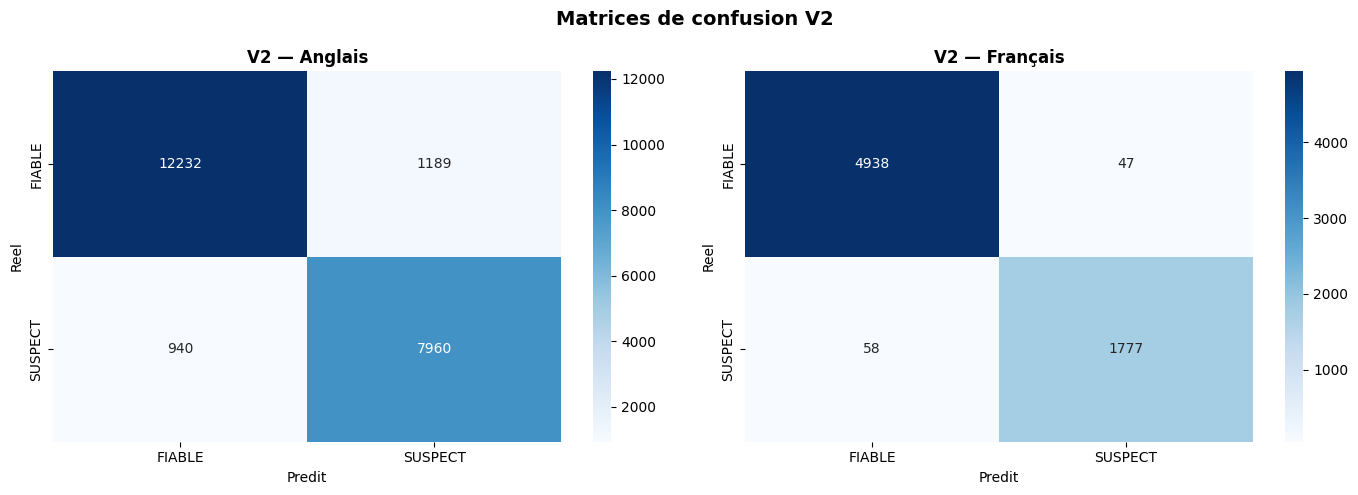

In [5]:
# Cell 5 — Evaluation detaillee V2 vs V1.5
from sklearn.metrics import classification_report, f1_score

print("\n" + "=" * 60)
print("EVALUATION V2 vs V1.5")
print("=" * 60)

# Charger le modele V1.5 sauvegarde
import pickle
v15_model_path = os.path.join(model_dir, 'expert_model.pkl')
detector_v15 = ExpertFakeNewsDetector(model_dir=model_dir)

# Predire avec V2 sur le test set
texts_test = pd.Series(df_test['text_clean'].values)
results_v2 = detector_v2.predict(texts_test)

y_true = df_test['label'].values
y_pred_v2 = results_v2['prediction_label'].values

print("\n--- Classification Report V2 (holdout 20%) ---")
print(classification_report(y_true, y_pred_v2, target_names=['FIABLE', 'SUSPECT']))

# Evaluation par longueur de texte
df_eval = df_test.copy()
df_eval['pred_v2'] = y_pred_v2
df_eval['word_len'] = df_eval['text_clean'].str.split().str.len()
df_eval['len_cat'] = pd.cut(df_eval['word_len'], bins=[0, 30, 100, 500, 10000],
                            labels=['Court (<30)', 'Moyen (30-100)', 'Long (100-500)', 'Tres long (500+)'])

print("\n--- F1 V2 par categorie de longueur ---")
for cat in df_eval['len_cat'].cat.categories:
    mask = df_eval['len_cat'] == cat
    if mask.sum() == 0:
        continue
    f1 = f1_score(df_eval.loc[mask, 'label'], df_eval.loc[mask, 'pred_v2'])
    n = mask.sum()
    print(f"  {cat}: F1={f1:.4f} (n={n})")

# Par langue
print("\n--- F1 V2 par langue ---")
for lang in ['en', 'fr']:
    mask = df_eval['language'] == lang
    if mask.sum() == 0:
        continue
    f1 = f1_score(df_eval.loc[mask, 'label'], df_eval.loc[mask, 'pred_v2'])
    n = mask.sum()
    print(f"  {lang.upper()}: F1={f1:.4f} (n={n})")

# Matrice de confusion V2
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lang, title in zip(axes, ['en', 'fr'], ['V2 — Anglais', 'V2 — Français']):
    mask = df_eval['language'] == lang
    if mask.sum() == 0:
        continue
    cm = confusion_matrix(df_eval.loc[mask, 'label'], df_eval.loc[mask, 'pred_v2'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FIABLE', 'SUSPECT'], yticklabels=['FIABLE', 'SUSPECT'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Reel')
    ax.set_xlabel('Predit')

plt.suptitle('Matrices de confusion V2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(_proj, 'docs', 'confusion_matrices_v2.png'), dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cell 6 — Test sur posts Bluesky
print("\n" + "=" * 60)
print("TEST SUR POSTS BLUESKY")
print("=" * 60)

# Connexion MongoDB
from pymongo import MongoClient

bluesky_posts = None
for uri in ['mongodb://localhost:27017/', 'mongodb://mongodb:27017/']:
    try:
        client = MongoClient(uri, serverSelectionTimeoutMS=2000)
        client.server_info()
        db = client['thumalien']
        coll = db['bluesky_posts']
        posts = list(coll.find(
            {'text': {'$exists': True, '$ne': ''}},
            {'text': 1, 'ai_score_credibility': 1, 'prediction_label': 1, '_id': 0}
        ).limit(1000))
        if posts:
            bluesky_posts = pd.DataFrame(posts)
            print(f"\n{len(bluesky_posts)} posts Bluesky charges depuis MongoDB")
        client.close()
        break
    except Exception as e:
        continue

if bluesky_posts is not None and len(bluesky_posts) > 0:
    texts_bsky = pd.Series(bluesky_posts['text'].values)

    # Predictions V2
    results_v2_bsky = detector_v2.predict(texts_bsky)
    bluesky_posts['v2_label'] = results_v2_bsky['prediction_label'].map({0: 'FIABLE', 1: 'SUSPECT'})
    bluesky_posts['v2_score'] = results_v2_bsky['ai_score_credibility'].values

    # Distribution V2
    v2_dist = bluesky_posts['v2_label'].value_counts()
    print(f"\nDistribution V2 sur Bluesky:")
    for label, count in v2_dist.items():
        print(f"  {label}: {count} ({count/len(bluesky_posts)*100:.1f}%)")

    # Ancien score RoBERTa si disponible
    has_legacy = 'ai_score_credibility' in bluesky_posts.columns
    if has_legacy:
        legacy_scores = pd.to_numeric(bluesky_posts['ai_score_credibility'], errors='coerce')
        has_legacy = legacy_scores.notna().sum() > 0

    # Histogramme des scores V2
    fig, axes = plt.subplots(1, 2 if has_legacy else 1, figsize=(14 if has_legacy else 7, 5))
    if not hasattr(axes, '__len__'):
        axes = [axes]

    axes[0].hist(bluesky_posts['v2_score'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2)
    axes[0].set_title('V2 — Scores de credibilite sur Bluesky', fontweight='bold')
    axes[0].set_xlabel('Score (0=suspect, 1=fiable)')
    axes[0].set_ylabel('Frequence')

    if has_legacy and len(axes) > 1:
        axes[1].hist(legacy_scores.dropna(), bins=50, color='coral', alpha=0.7, edgecolor='white')
        axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2)
        axes[1].set_title('Legacy RoBERTa — Scores', fontweight='bold')
        axes[1].set_xlabel('Score')
        axes[1].set_ylabel('Frequence')

    plt.suptitle('Distribution des scores sur posts Bluesky', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(_proj, 'docs', 'bluesky_scores_v2.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Exemples V2
    print("\n--- 5 posts les plus FIABLES (V2) ---")
    top_fiable = bluesky_posts.nlargest(5, 'v2_score')
    for _, row in top_fiable.iterrows():
        print(f"  [{row['v2_score']:.3f}] {row['text'][:120]}")

    print("\n--- 5 posts les plus SUSPECTS (V2) ---")
    top_suspect = bluesky_posts.nsmallest(5, 'v2_score')
    for _, row in top_suspect.iterrows():
        print(f"  [{row['v2_score']:.3f}] {row['text'][:120]}")

    print("\n--- 5 posts les plus INCERTAINS (V2, score ~0.5) ---")
    bluesky_posts['dist_05'] = abs(bluesky_posts['v2_score'] - 0.5)
    incertains = bluesky_posts.nsmallest(5, 'dist_05')
    for _, row in incertains.iterrows():
        print(f"  [{row['v2_score']:.3f}] {row['text'][:120]}")
else:
    print("\nMongoDB non disponible ou aucun post — section Bluesky ignoree")


TEST SUR POSTS BLUESKY



MongoDB non disponible ou aucun post — section Bluesky ignoree


In [7]:
# Cell 7 — Sauvegarde et conclusions
print("\n" + "=" * 60)
print("SAUVEGARDE ET CONCLUSIONS")
print("=" * 60)

# Sauvegarder V2
detector_v2.save('expert_v2')
print(f"\nModele V2 sauvegarde dans {model_dir} (suffix=expert_v2)")

# Resume comparatif
print("\n--- Resume V1.5 vs V2 ---")
print(f"  V1.5 : {len(df_v15)} articles, F1 CV ~0.986")
print(f"  V2   : {len(df_v2)} articles (+{len(df_v2)-len(df_v15)})")
print(f"  V2 CV F1 : {metrics_v2.get('f1', 'N/A')}")

if bluesky_posts is not None and 'v2_label' in bluesky_posts.columns:
    pct_suspect_v2 = (bluesky_posts['v2_label'] == 'SUSPECT').mean() * 100
    print(f"\n  Bluesky V2 : {pct_suspect_v2:.1f}% suspect (V1.5 etait 77%)")
    if pct_suspect_v2 < 77:
        print("  → Amelioration de la calibration sur textes courts")
    else:
        print("  → La calibration n'a pas significativement change")

print("\n--- Recommandations ---")
print("  1. Le V2 integre titres d'articles + tweets = meilleure diversite de longueur")
print("  2. Pour V3 : envisager sentence-transformers pour embeddings semantiques")
print("  3. L'oversampling social x2 equilibre articles longs et textes courts")
print("\nNotebook 08 termine avec succes.")


SAUVEGARDE ET CONCLUSIONS



Modele V2 sauvegarde dans /Users/azeliebernard/Documents/MASTER Big data/projet_etude/models (suffix=expert_v2)

--- Resume V1.5 vs V2 ---
  V1.5 : 65517 articles, F1 CV ~0.986
  V2   : 145703 articles (+80186)
  V2 CV F1 : N/A

--- Recommandations ---
  1. Le V2 integre titres d'articles + tweets = meilleure diversite de longueur
  2. Pour V3 : envisager sentence-transformers pour embeddings semantiques
  3. L'oversampling social x2 equilibre articles longs et textes courts

Notebook 08 termine avec succes.
